In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

from scipy.interpolate import interp1d
from scipy.interpolate import griddata

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
from scipy import stats

def binned_mean(x, y, bins):
    from scipy import stats
    bin_center, bin_mean = np.full((2, len(bins)-1), np.nan)
    for index in range(len(bins)-1):
        mask = (x>=bins[index]) & (x<bins[index+1])
        if np.sum(mask)>0:
            bin_center[index] = np.mean(x[mask])
            bin_mean[index] = np.mean(y[mask])
    return bin_center, bin_mean

In [4]:
cat_stack = []

for field in ['north', 'south']:
    cat = Table(fitsio.read('/Users/rongpu/Documents/Data/lrg_xcorr/magnification/lrg_magnification_{}.fits'.format(field)))
    cat1 = Table(fitsio.read('/Users/rongpu/Documents/Data/lrg_xcorr/magnification/lrg_magnification_{}_fiberflux.fits'.format(field)))
    if field=='north':
        cat1['PHOTSYS'] = 'N'
    else:
        cat1['PHOTSYS'] = 'S'
    cat_stack.append(hstack([cat, cat1]))

cat = vstack(cat_stack)

In [5]:
maskbits = [1, 8, 9, 11, 12, 13]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

min_nobs = 2
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

0.10388758331432311
11564639
11040165


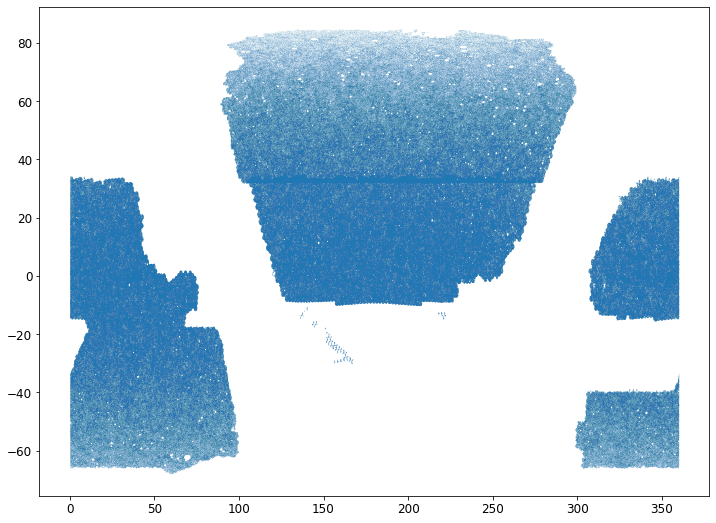

In [6]:
plt.figure(figsize=(12, 9))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.1, alpha=0.1)
plt.show()

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [8]:
mask_south = cat['PHOTSYS']=='S'
mask_north = cat['PHOTSYS']=='N'

21.610804
21.620804


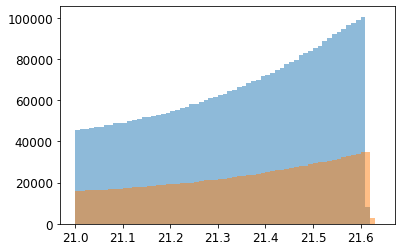

In [9]:
print(np.max(cat['zfibermag'][mask_south]))
print(np.max(cat['zfibermag'][mask_north]))

bins = np.arange(21, 21.65, 0.01)

plt.hist(cat['zfibermag'][mask_south], bins=bins, alpha=0.5)
plt.hist(cat['zfibermag'][mask_north], bins=bins, alpha=0.5)
plt.show()

In [10]:
# mask = np.full(len(cat), False)
# mask |= mask_north & (cat['zfibermag']>21.59)
# mask |= mask_south & (cat['zfibermag']>21.58)
# cat = cat[mask]
# print(len(cat))

# mask_south = cat['PHOTSYS']=='S'
# mask_north = cat['PHOTSYS']=='N'
# print(np.sum(mask_south))
# print(np.sum(mask_north))

In [11]:
# print(np.min(cat['zfibermag'][mask_south]))
# print(np.min(cat['zfibermag'][mask_north]))

# bins = np.arange(21, 21.65, 0.01)

# plt.hist(cat['zfibermag'][mask_south], alpha=0.5)
# plt.hist(cat['zfibermag'][mask_north], alpha=0.5)
# plt.show()

In [12]:
# axis ratio
e = np.array(np.sqrt(cat['SHAPE_E1']**2+cat['SHAPE_E2']**2))
q = (1+e)/(1-e)

In [13]:
t = Table()
t['type'], t['count'] = np.unique(cat['TYPE'], return_counts=True)
t['frac (%)'] = t['count']/len(cat)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

type,count,frac (%)
str3,int64,float64
PSF,247060,2.2
EXP,1097499,9.9
SER,1737312,15.7
REX,3248054,29.4
DEV,4710240,42.7


In [14]:
t = Table()
t['type'], t['count'] = np.unique(cat['TYPE'][mask_south], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask_south)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

type,count,frac (%)
str3,int64,float64
PSF,170497,2.1
EXP,788476,9.7
SER,1442760,17.7
REX,2292130,28.1
DEV,3462894,42.5


In [15]:
t = Table()
t['type'], t['count'] = np.unique(cat['TYPE'][mask_north], return_counts=True)
t['frac (%)'] = t['count']/np.sum(mask_north)*100
t['frac (%)'].format = '%.1f'
t.sort('count')
t

type,count,frac (%)
str3,int64,float64
PSF,76563,2.7
SER,294552,10.2
EXP,309023,10.7
REX,955924,33.2
DEV,1247346,43.3


-------
# REX

In [16]:
data_rex = np.load('data/rex.npz')
print(data_rex.files)
ratio_interp_rex = interp1d(data_rex['shape_r'], data_rex['ratio'], bounds_error=False, fill_value='extrapolate', kind='quadratic')

['shape_r', 'ratio', 'f_factor']


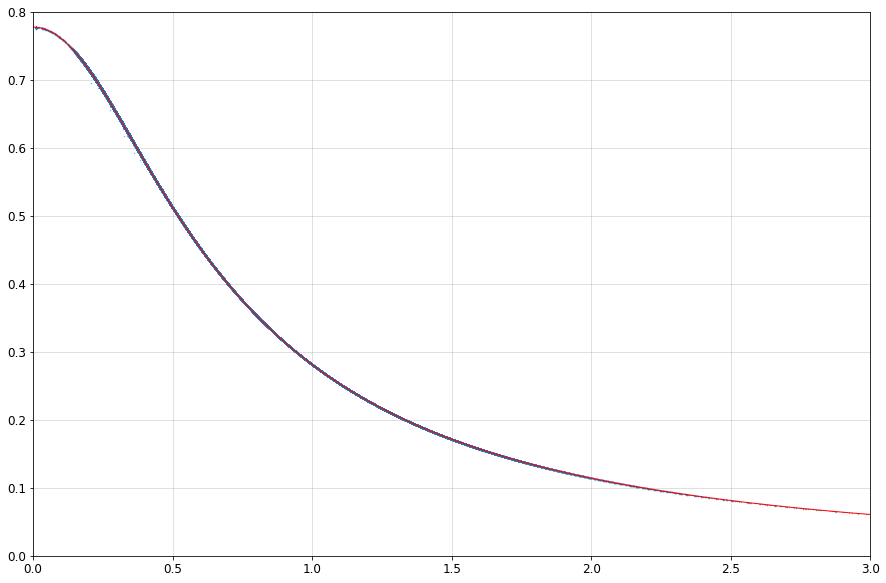

In [17]:
mask = cat['TYPE']=='REX'
x, y = cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask]
q_mean = np.mean(q[mask])

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x, y, '.', ms=0.5)
plt.plot(x_plot, ratio_interp_rex(x_plot), lw=1, color='r')
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

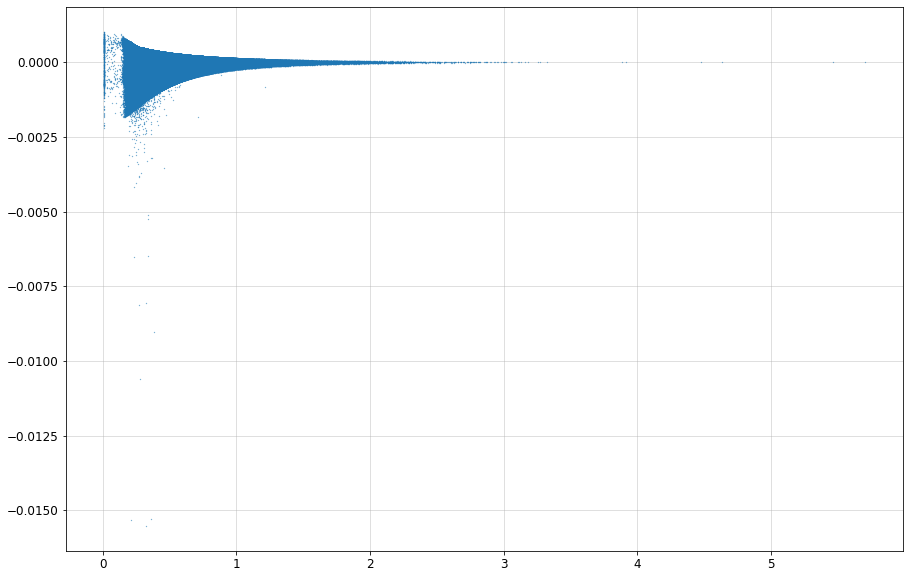

In [18]:
plt.figure(figsize=(15, 10))
plt.plot(x, y-cat['ff_ratio'][mask], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

-------
# EXP

In [19]:
data_exp = np.load('data/exp_fiber_ratio.npz')
print(data_exp.files)
data_exp['shape_r'], data_exp['q'], data_exp['ratio']

def ratio_interp_exp(r, q):
    q = np.clip(q, 1.03, 9.98)
    r = np.clip(r, 0., 9.99)
    return griddata(np.array([data_exp['shape_r'], data_exp['q']]).T, data_exp['ratio'], (r, q), method='cubic')

['shape_r', 'q', 'ratio']


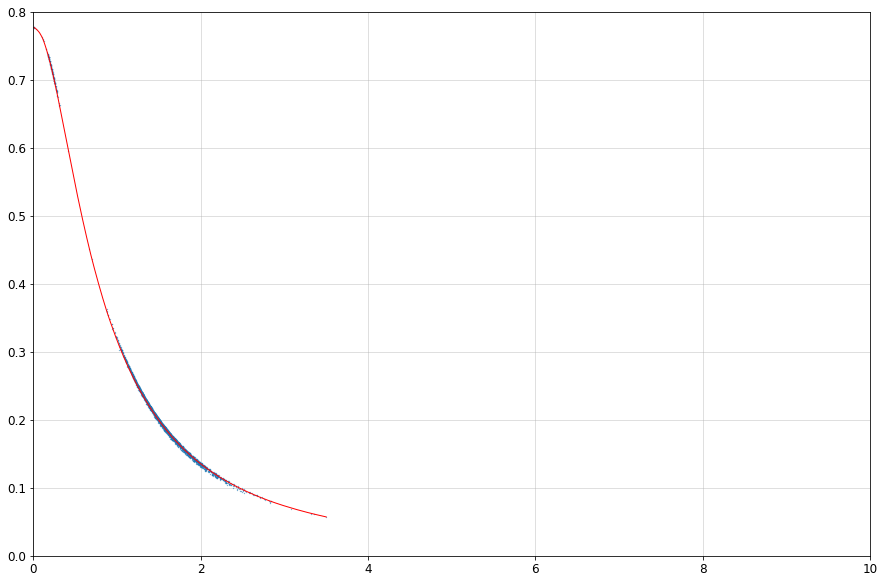

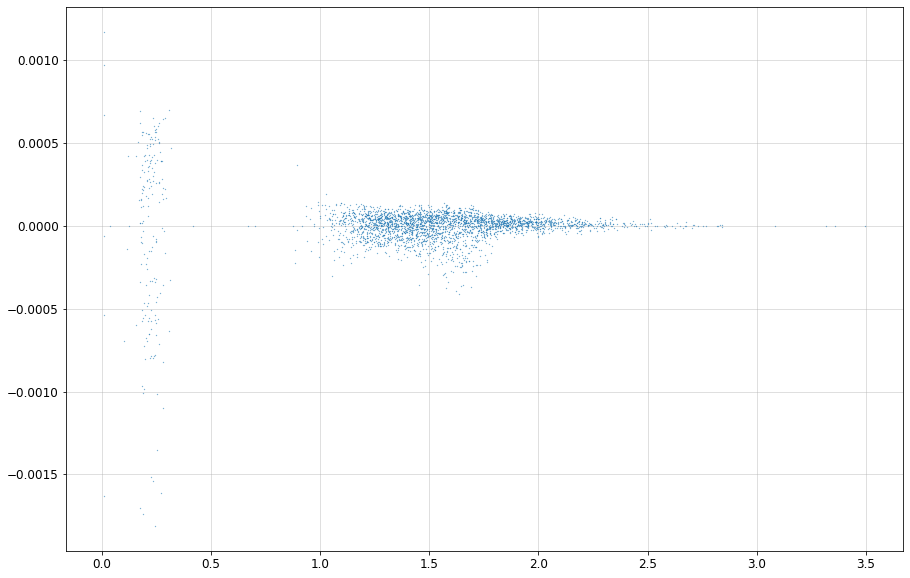

In [20]:
mask = cat['TYPE']=='EXP'
mask &= (q>1.2) & (q<1.3)
x, y = cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask]
q_mean = np.mean(q[mask])

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x, y, '.', ms=0.5)
plt.plot(x_plot, ratio_interp_exp(x_plot, q_mean), lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x, y-cat['ff_ratio'][mask], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

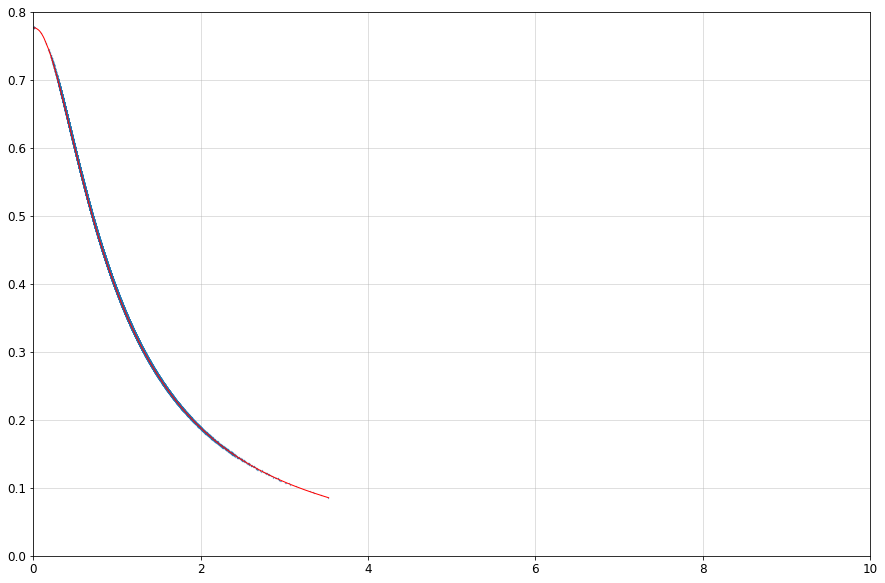

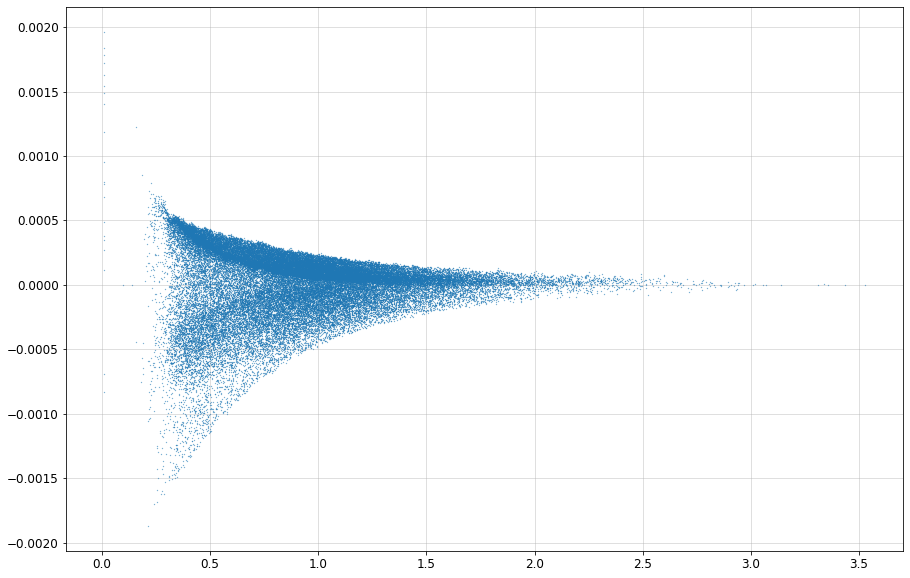

In [21]:
mask = cat['TYPE']=='EXP'
mask &= (q>2.2) & (q<2.3)
x, y = cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask]
q_mean = np.mean(q[mask])

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x, y, '.', ms=0.5)
plt.plot(x_plot, ratio_interp_exp(x_plot, q_mean), lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x, y-cat['ff_ratio'][mask], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

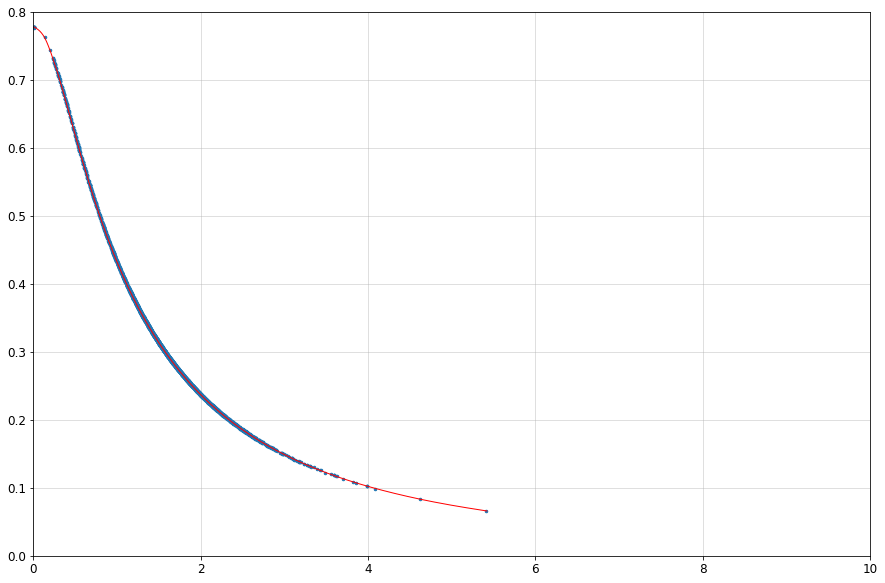

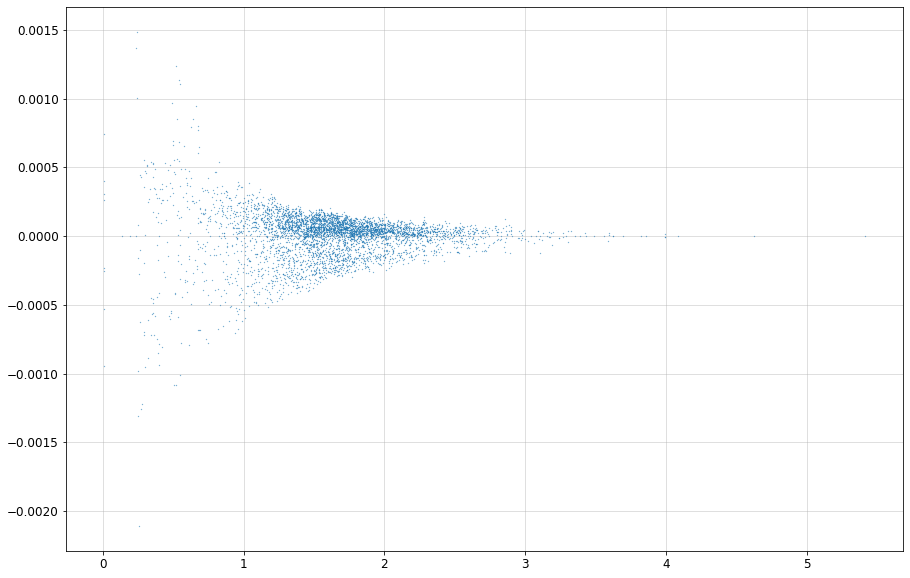

In [22]:
mask = cat['TYPE']=='EXP'
mask &= (q>4.2) & (q<4.3)
x, y = cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask]
q_mean = np.mean(q[mask])

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x, y, '.', ms=5)
plt.plot(x_plot, ratio_interp_exp(x_plot, q_mean), lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x, y-cat['ff_ratio'][mask], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

-------
# DEV

In [23]:
data_dev = np.load('data/dev_fiber_ratio.npz')
print(data_dev.files)
data_dev['shape_r'], data_dev['q'], data_dev['ratio']

def ratio_interp_dev(r, q):
    q = np.clip(q, 1.03, 9.98)
    r = np.clip(r, 0., 9.99)
    return griddata(np.array([data_dev['shape_r'], data_dev['q']]).T, data_dev['ratio'], (r, q), method='cubic')

['shape_r', 'q', 'ratio']


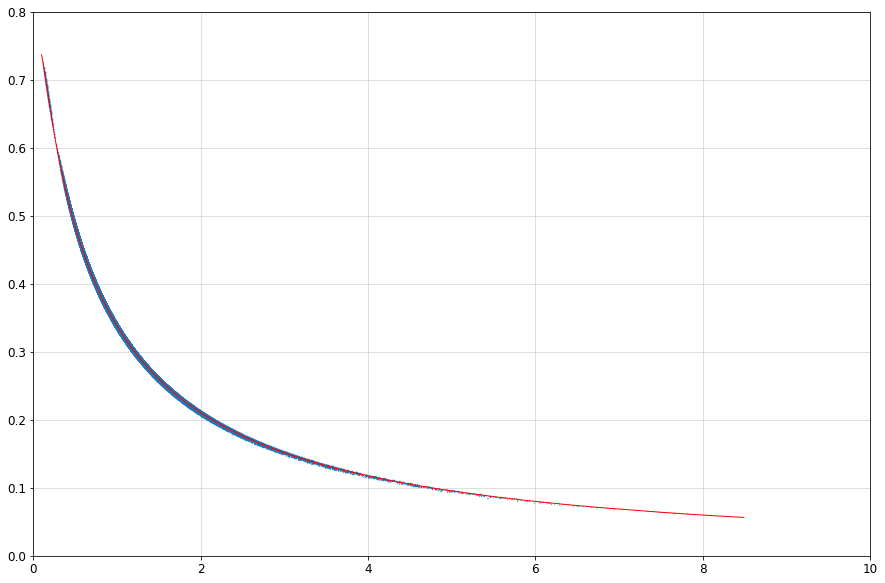

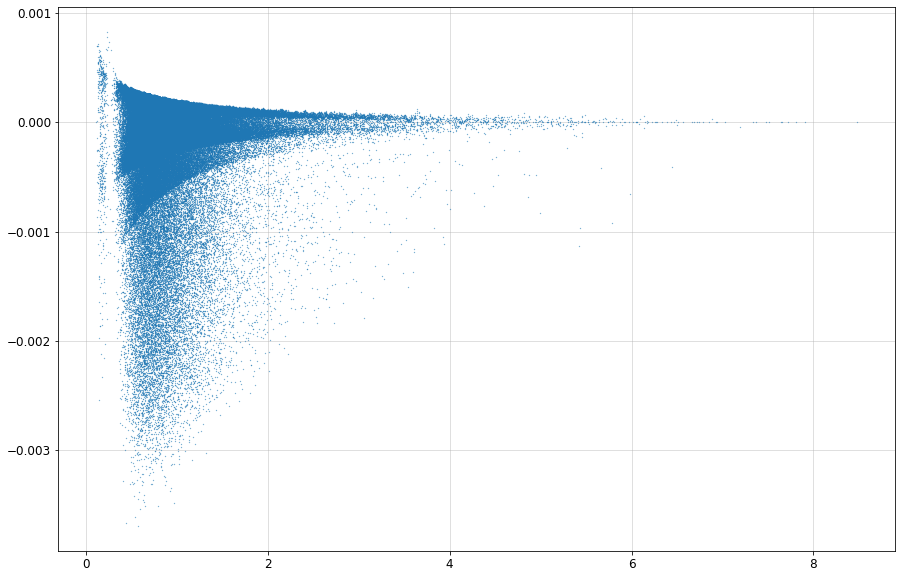

In [24]:
mask = cat['TYPE']=='DEV'
mask &= (q>1.) & (q<1.1)
x, y = cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask]
q_mean = np.mean(q[mask])

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x, y, '.', ms=0.5)
plt.plot(x_plot, ratio_interp_dev(x_plot, q_mean), lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x, y-cat['ff_ratio'][mask], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

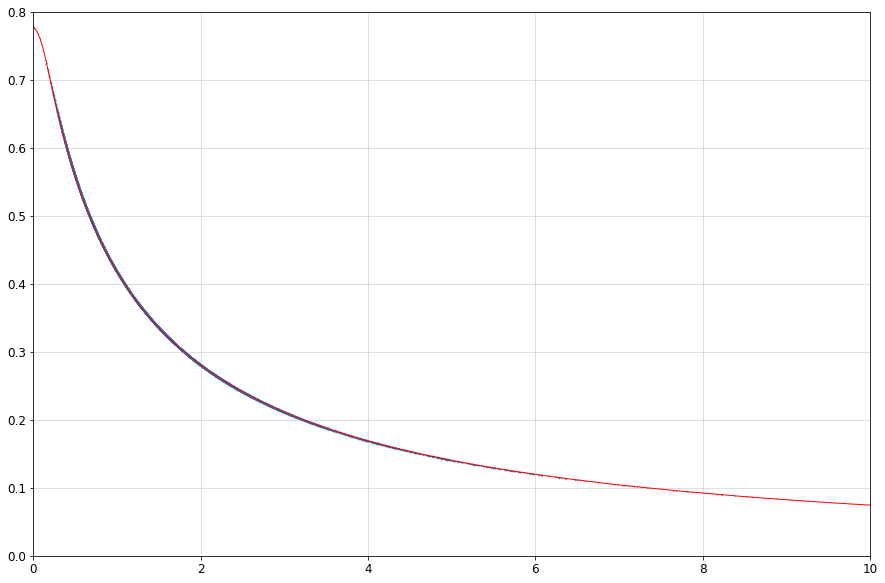

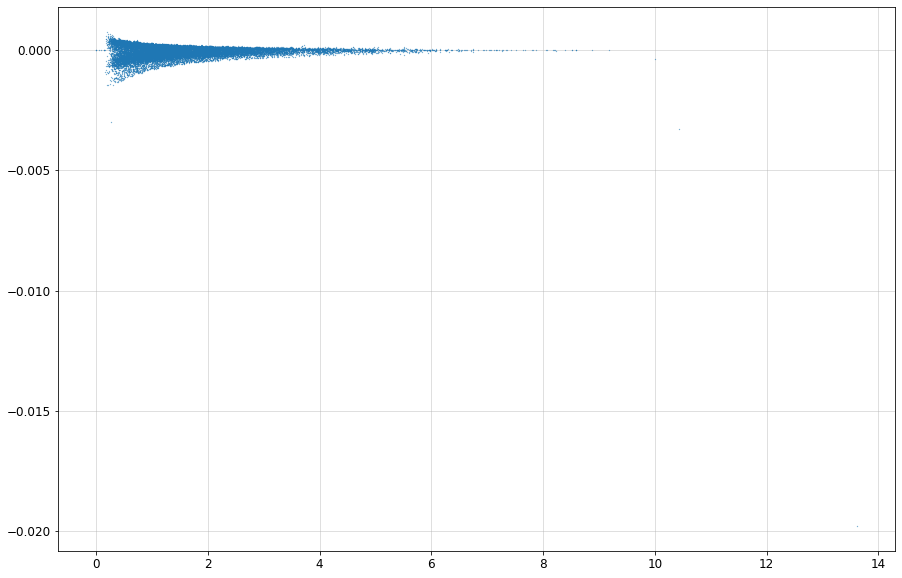

In [25]:
mask = cat['TYPE']=='DEV'
mask &= (q>3.) & (q<3.1)
x, y = cat['SHAPE_R'][mask], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])[mask]
q_mean = np.mean(q[mask])

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x, y, '.', ms=0.5)
plt.plot(x_plot, ratio_interp_dev(x_plot, q_mean), lw=1, color='r')
plt.axis([0, 10, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x, y-cat['ff_ratio'][mask], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

-------
# SER

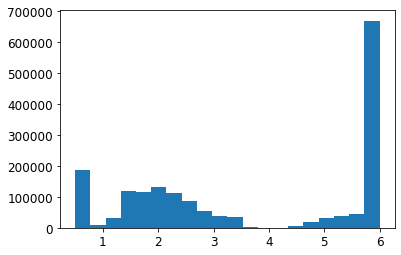

In [26]:
mask = cat['TYPE']=='SER'
plt.hist(cat['SERSIC'][mask], 20)
plt.show()

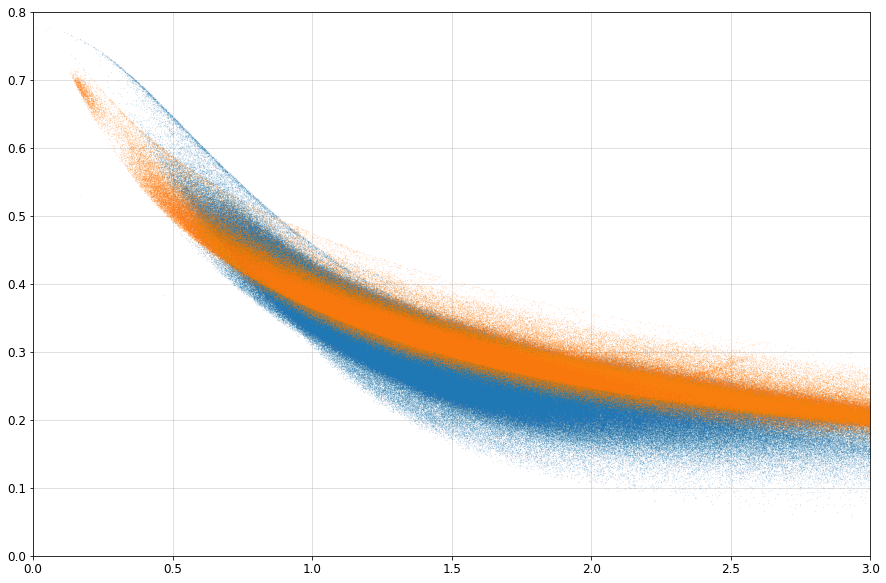

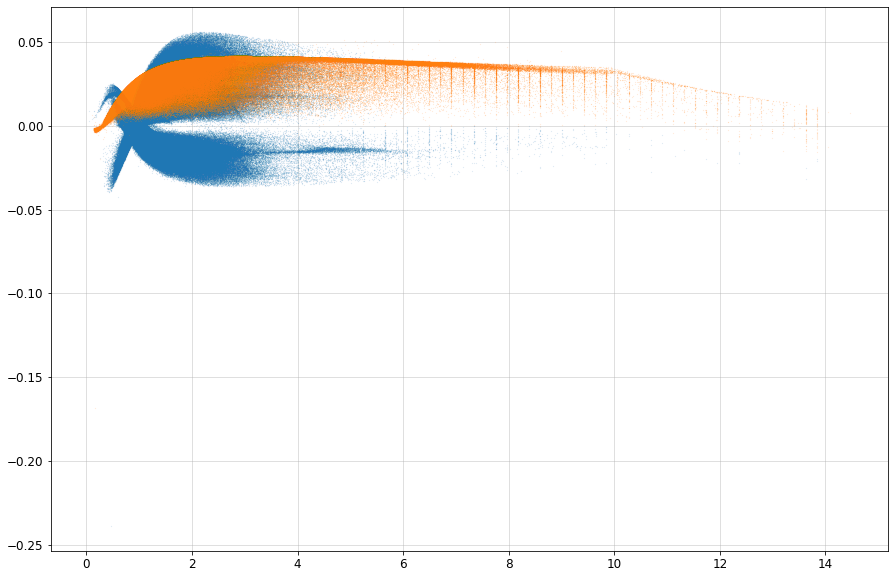

In [27]:
x, y = cat['SHAPE_R'], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])

mask = cat['TYPE']=='SER'
mask1 = mask & (cat['SERSIC']<4)
mask2 = mask & (cat['SERSIC']>=4)
q_mean = np.mean(q[mask])

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1], '.', ms=0.1)
plt.plot(x[mask2], y[mask2], '.', ms=0.1)
# plt.plot(x_plot, ratio_interp_rex(x_plot), lw=1, color='r')
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1]-cat['ff_ratio'][mask1], '.', ms=0.1)
plt.plot(x[mask2], y[mask2]-cat['ff_ratio'][mask2], '.', ms=0.1)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

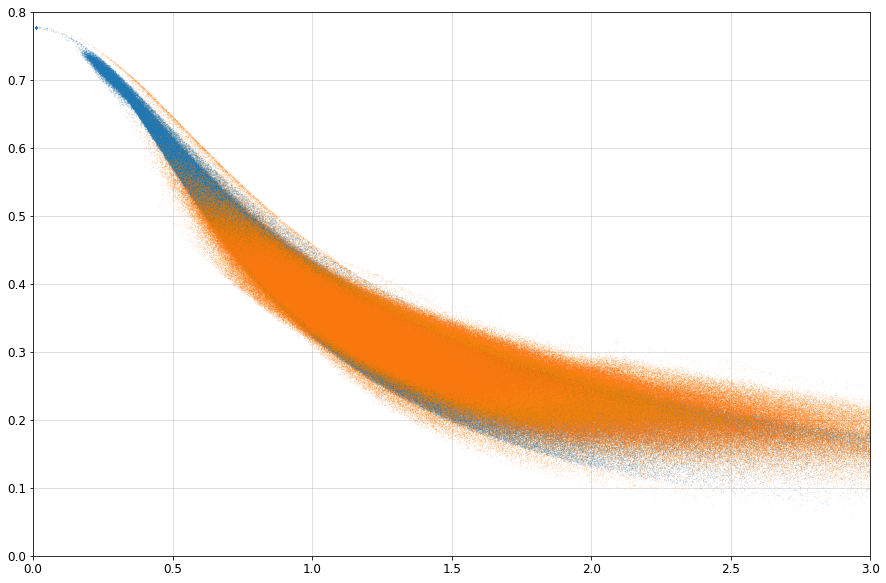

In [28]:
x, y = cat['SHAPE_R'], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])

mask = cat['TYPE']=='SER'
mask1 = mask & (cat['SERSIC']<4)
q_mean = np.mean(q[mask])

mask2 = (cat['TYPE']=='EXP')

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x[mask2], y[mask2], '.', ms=0.1)
plt.plot(x[mask1], y[mask1], '.', ms=0.1)
# plt.plot(x_plot, ratio_interp_rex(x_plot), lw=1, color='r')
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

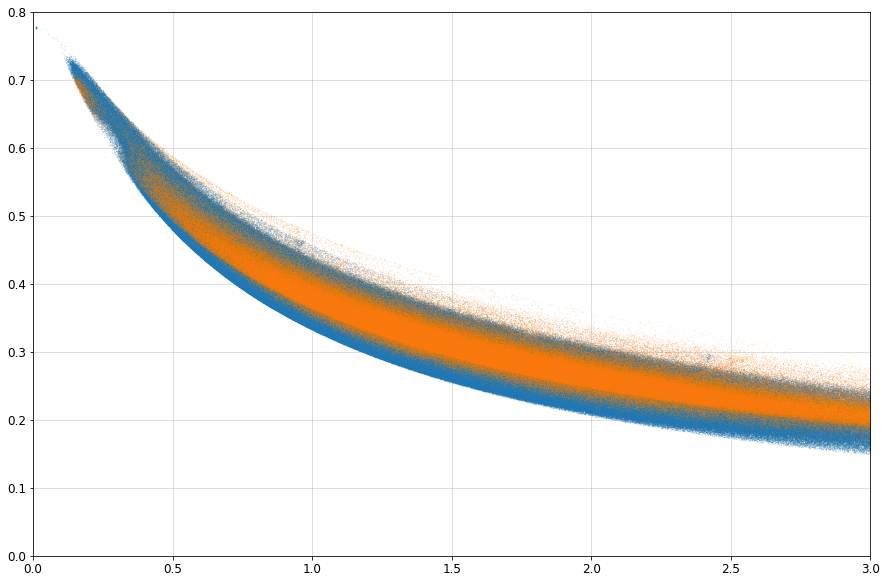

In [29]:
x, y = cat['SHAPE_R'], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])

mask = cat['TYPE']=='SER'
mask1 = mask & (cat['SERSIC']>=4)
q_mean = np.mean(q[mask])

mask2 = (cat['TYPE']=='DEV')

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x[mask2], y[mask2], '.', ms=0.1)
plt.plot(x[mask1], y[mask1], '.', ms=0.1)
# plt.plot(x_plot, ratio_interp_rex(x_plot), lw=1, color='r')
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

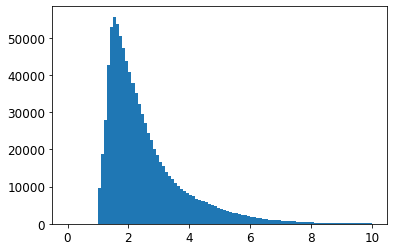

In [30]:
mask = cat['TYPE']=='SER'
mask1 = mask & (cat['SERSIC']<4)

plt.hist(q[mask1], 100, range=(0, 10));

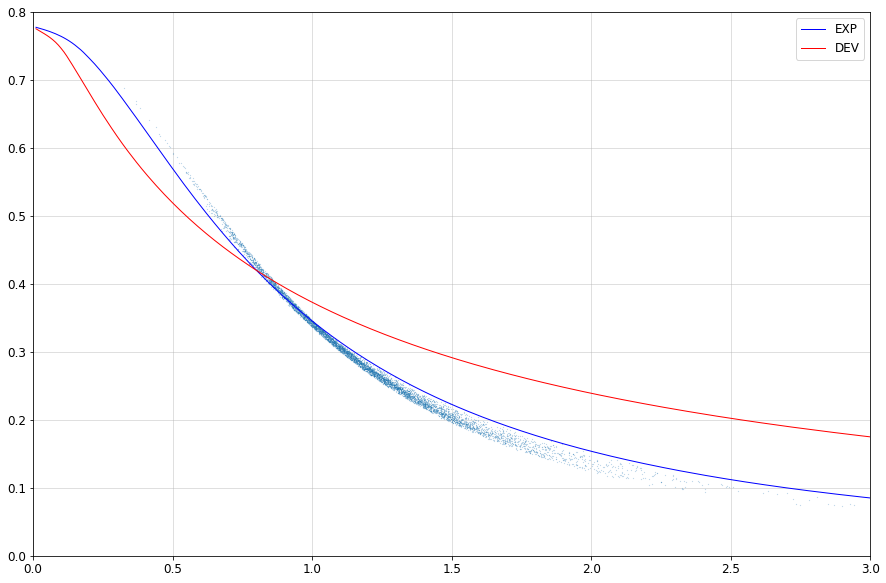

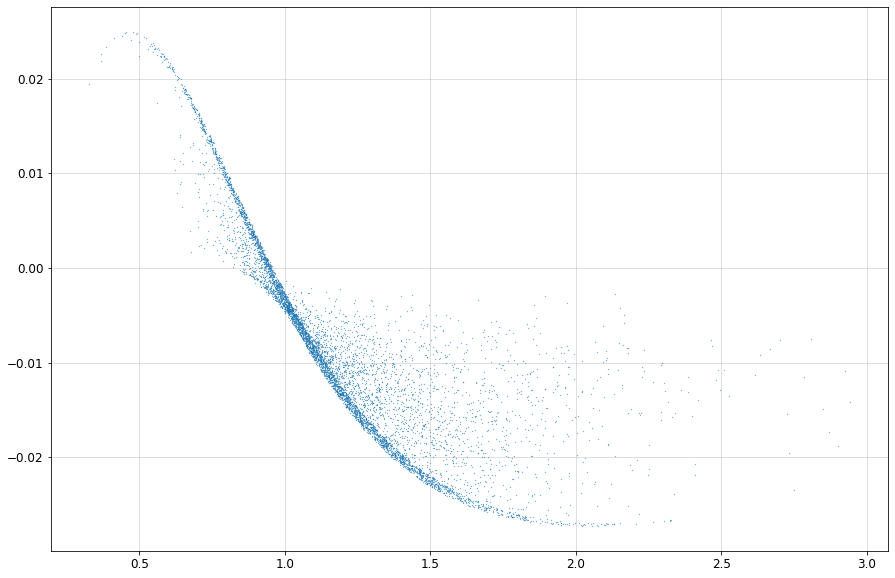

In [31]:
x, y = cat['SHAPE_R'], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])

mask = cat['TYPE']=='SER'
mask1 = mask & (cat['SERSIC']<1)
mask1 &= (q>1.5) & (q<1.6)
q_mean = np.mean(q[mask1])

mask2 = (cat['TYPE']=='EXP')

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1], '.', ms=0.2)
plt.plot(x_plot, ratio_interp_exp(x_plot, q_mean), lw=1, color='b', label='EXP')
plt.plot(x_plot, ratio_interp_dev(x_plot, q_mean), lw=1, color='r', label='DEV')
# plt.plot(x_plot, ratio_interp_rex(x_plot), lw=1, color='r')
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1]-cat['ff_ratio'][mask1], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

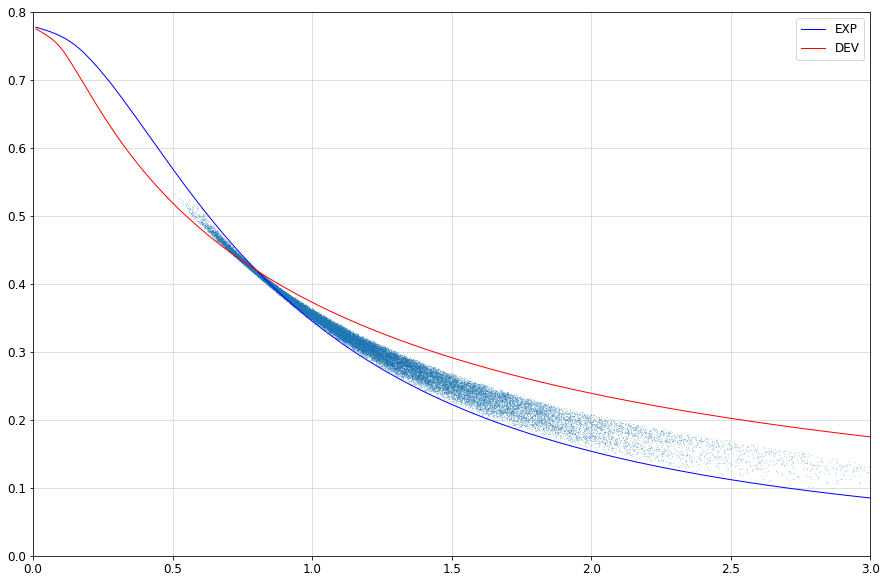

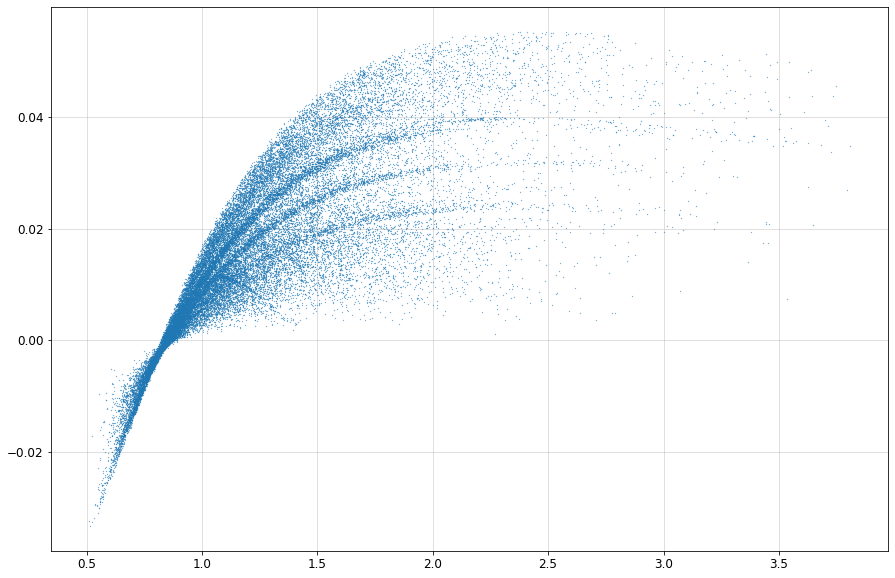

In [32]:
x, y = cat['SHAPE_R'], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])

mask = cat['TYPE']=='SER'
mask1 = mask & (cat['SERSIC']>=1) & (cat['SERSIC']<2.5)
mask1 &= (q>1.5) & (q<1.6)
q_mean = np.mean(q[mask1])

mask2 = (cat['TYPE']=='EXP')

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1], '.', ms=0.2)
plt.plot(x_plot, ratio_interp_exp(x_plot, q_mean), lw=1, color='b', label='EXP')
plt.plot(x_plot, ratio_interp_dev(x_plot, q_mean), lw=1, color='r', label='DEV')
# plt.plot(x_plot, ratio_interp_rex(x_plot), lw=1, color='r')
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1]-cat['ff_ratio'][mask1], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

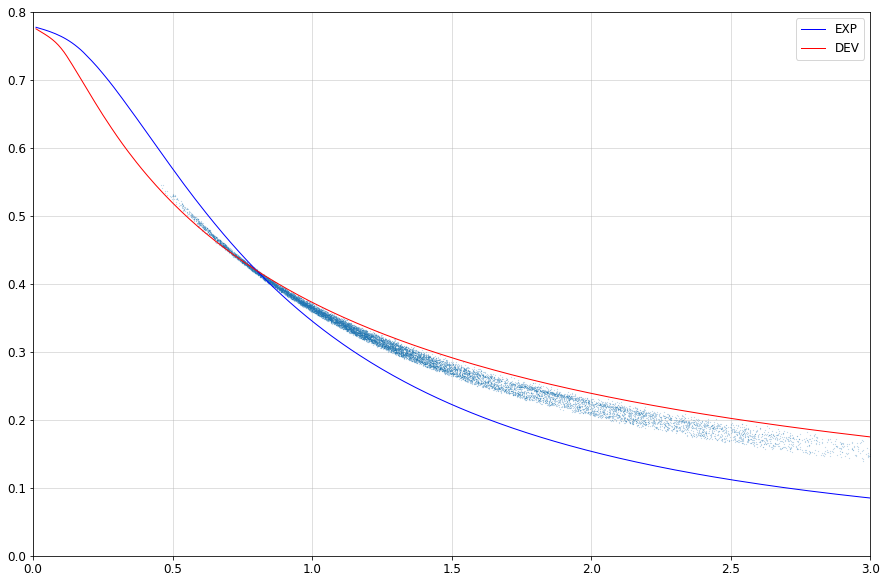

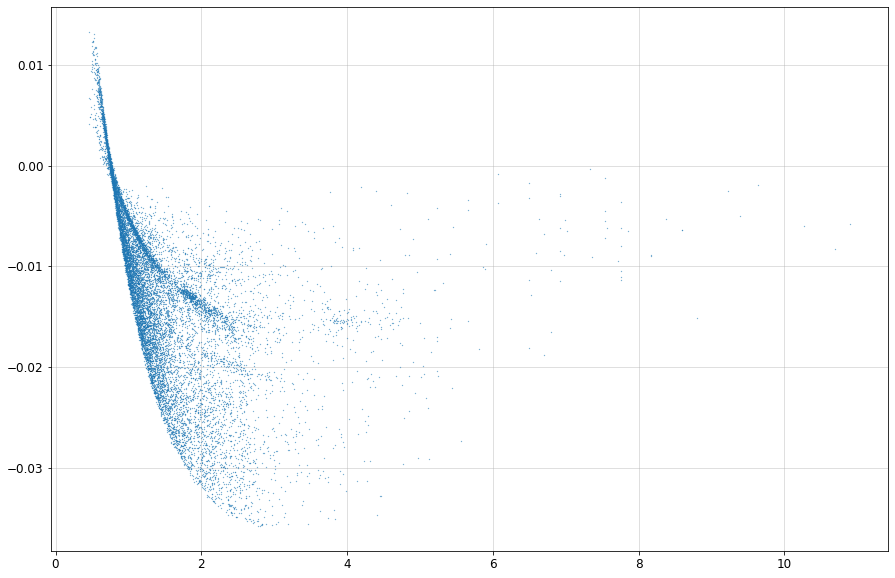

In [33]:
x, y = cat['SHAPE_R'], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])

mask = cat['TYPE']=='SER'
mask1 = mask & (cat['SERSIC']>=2.5) & (cat['SERSIC']<4)
mask1 &= (q>1.5) & (q<1.6)
q_mean = np.mean(q[mask1])

mask2 = (cat['TYPE']=='EXP')

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1], '.', ms=0.2)
plt.plot(x_plot, ratio_interp_exp(x_plot, q_mean), lw=1, color='b', label='EXP')
plt.plot(x_plot, ratio_interp_dev(x_plot, q_mean), lw=1, color='r', label='DEV')
# plt.plot(x_plot, ratio_interp_rex(x_plot), lw=1, color='r')
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1]-cat['ff_ratio'][mask1], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

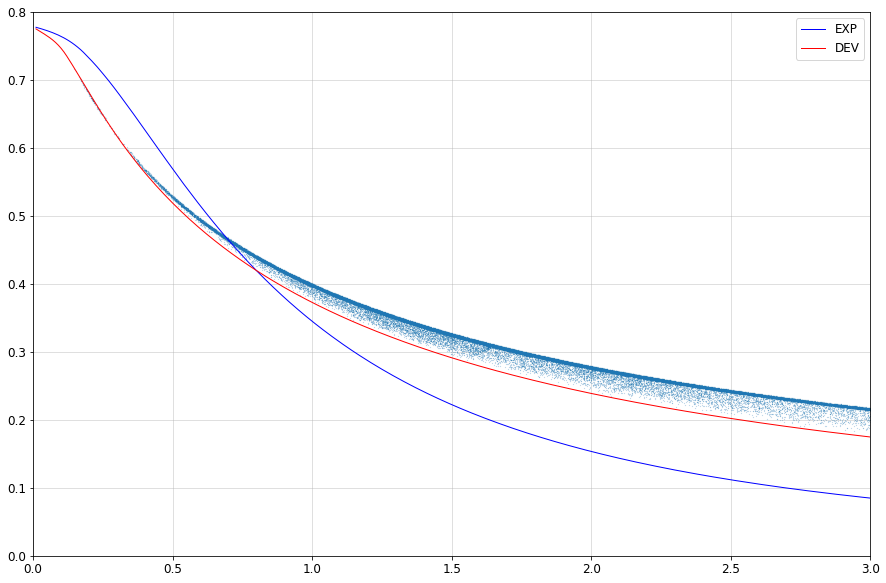

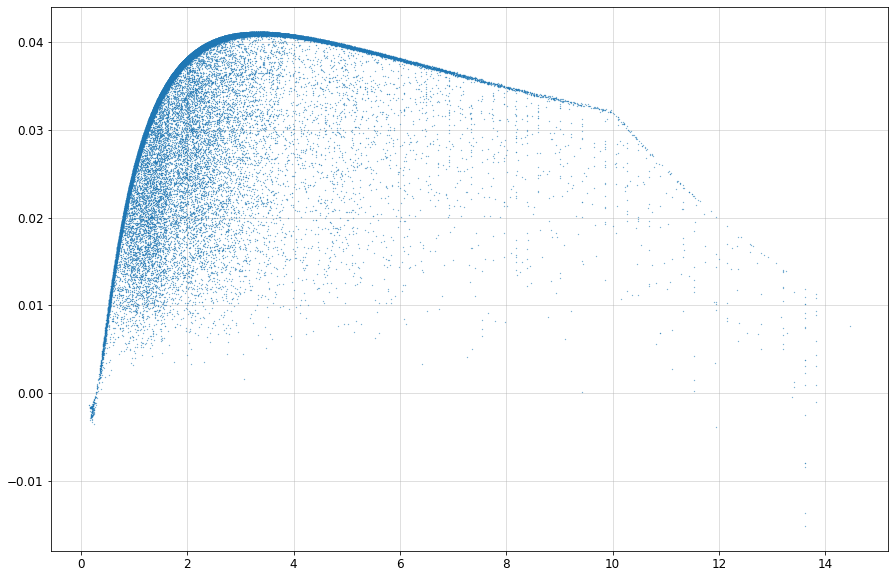

In [34]:
x, y = cat['SHAPE_R'], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])

mask = cat['TYPE']=='SER'
mask1 = mask & (cat['SERSIC']>=4)
mask1 &= (q>1.5) & (q<1.6)
q_mean = np.mean(q[mask1])

mask2 = (cat['TYPE']=='EXP')

x_plot = np.arange(0., np.max(x)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1], '.', ms=0.2)
plt.plot(x_plot, ratio_interp_exp(x_plot, q_mean), lw=1, color='b', label='EXP')
plt.plot(x_plot, ratio_interp_dev(x_plot, q_mean), lw=1, color='r', label='DEV')
# plt.plot(x_plot, ratio_interp_rex(x_plot), lw=1, color='r')
plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(15, 10))
plt.plot(x[mask1], y[mask1]-cat['ff_ratio'][mask1], '.', ms=0.5)
# plt.axis([0, 3, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()